# IT Support Dashboard - Supporting Notebook 4

This series of notebooks contains supporting documentation for the full report. Here, we provide quality checks for the full dataset, confirm whether the English-only sample is representative of the full population available, and conduct text analytics.

## Clustering & Actionability Scoring

Notebook 4 groups thousands of support tickets into interpretable issue clusters, automatically labelled by topic and ranked by business relevance. This was done using K-Means clustering on TF-IDF vectors, with cluster quality assessed by silhouette scores and redundancy ratios. Clusters were then assessed using cohesion and prevalence characteristics to derive an actionability score, enabling prioritisation of operational improvements.

The following steps were taken:
- Applied K-Means clustering on normalised TF-IDF vectors
- Tested k values in a configured search range with median-cluster thresholds of 1%, 1.5%, and 2%
- Selected final K using a composite score balancing silhouette (cohesion/separation) and redundancy ratio (theme overlap)
- Generated interpretable cluster labels from the top TF-IDF terms per cluster
- Calculated intra-cluster mean similarity (cohesion) and cluster prevalence (share of tickets)
- Derived a composite actionability score combining prevalence-weighted cohesion and high-similarity concentration


### Importing

First, the required packages for this process were imported, the necessary folders were created using the config file, and the clean dataset was read.

In [4]:
# Importing essential packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time
from scipy import sparse

# Add project root to sys.path by searching upward for config.py
project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists()), None
)
if project_root is None:
    raise FileNotFoundError("Could not locate project root containing config.py")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config import Config

Config.ensure_directories()

# Reading the sparse TF-IDF matrix
print("\nTF-IDF matrix dataframe:")
df = pd.read_parquet(Config.TFIDF_MATRIX_PATH, engine="pyarrow")
display(df)

[Config] Verified project directory structure under C:\Users\David\Desktop\Python_Files\IT-Support-Ticket-Analysis

TF-IDF matrix dataframe:


,ability,able,ableton,ableton live,accept,access,access alert,access attempt,access control,access datum,...,write report,write request,xero,xonar,yield,zapier,zoho,zoho books,zoho crm,zoom
0,0.0,0.000000,0.0,0.0,0.000000,0.09995,0.0,0.0,0.0,0.0,...,0.108672,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.189277,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.139654,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13724,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13725,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13726,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13727,0.0,0.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Evaluating K values

First, we evaluated K values from 20 to 80 to find the optimal number of clusters. We used the silhouette score to measure how well samples were clustered (cohesion and separation) and a redundancy ratio to measure how distinct the clusters were in terms of their top TF-IDF features. We also recorded the time taken for each K to evaluate the computational cost.

In [5]:
# Normalise TF-IDF once and keep it sparse for faster clustering
tfidf_sparse = sparse.csr_matrix(df.to_numpy(dtype=np.float32))
tfidf_normalised = normalize(tfidf_sparse, norm="l2", copy=False)
n_samples = tfidf_normalised.shape[0]  # use the actual sample being clustered

In [3]:
# Define k search range and threshold candidates from config
k_values = Config.K_SEARCH_RANGE

print(
    f"Evaluating KMeans clustering metrics across k values ({min(k_values)}-{max(k_values)}) "
    "(60-90mins)..."
)

# Convert the full sparse matrix to dense for full-dataset metric calculations
tfidf_dense = tfidf_sparse.toarray()

# Compute clustering metrics once per k
records = []
print(
    f"Evaluating KMeans for k={min(k_values)}-{max(k_values)} "
    f"(cut-offs based on n={n_samples:,})..."
)

# Identify k values that yield median cluster sizes around the defined thresholds
for k in k_values:
    # Record runtime because this is the most expensive step
    start_time = time.time()
    kmeans_model = KMeans(n_clusters=k, random_state=Config.RANDOM_STATE, n_init=10)
    cluster_labels = kmeans_model.fit_predict(tfidf_normalised)

    # Compute silhouette and Davies-Bouldin scores on the full dataset.
    unique_labels = np.unique(cluster_labels)
    if unique_labels.size > 1:
        silhouette_avg = silhouette_score(tfidf_dense, cluster_labels)
        davies_bouldin_avg = davies_bouldin_score(tfidf_dense, cluster_labels)
    else:
        silhouette_avg = np.nan
        davies_bouldin_avg = np.nan

    cluster_sizes = np.bincount(cluster_labels)
    median_cluster_size = float(np.median(cluster_sizes))
    runtime_seconds = time.time() - start_time

    # Record results for this k
    records.append(
        {
            "K Value": k,
            "Silhouette Score": silhouette_avg,
            "Davies-Bouldin Score": davies_bouldin_avg,
            "Median Cluster Size": median_cluster_size,
            "Runtime (sec)": runtime_seconds,
        }
    )

    # Print progress for this k
    print(
        f"k={k:<2d} | silhouette={silhouette_avg:.5f} | DB={davies_bouldin_avg:.3f} | "
        f"median={median_cluster_size:.0f} | runtime={runtime_seconds:.1f}s"
    )

# Compile results into a DataFrame and sort by K Value
metrics_df = pd.DataFrame(records).sort_values("K Value").reset_index(drop=True)
metrics_df["Silhouette Score (x10e-2)"] = metrics_df["Silhouette Score"] * 100

# Save metrics to CSV for sharing and to parquet to skip this cell in future runs
metrics_df.to_csv(Config.KMEANS_CSV_PATH, index=False, encoding="utf-8")
metrics_df.to_parquet(
    Config.KMEANS_PARQUET_PATH, engine="pyarrow", compression="snappy"
)

display(
    metrics_df.style.format(
        {
            "Silhouette Score": "{:.3f}",
            "Davies-Bouldin Score": "{:.3f}",
            "Median Cluster Size": "{:.0f}",
            "Runtime (sec)": "{:.1f}",
        }
    )
)

# Release dense matrix now that metric computation is complete
del tfidf_dense

Evaluating KMeans clustering metrics across k values (20-80) (60-90mins)...
Evaluating KMeans for k=20-80 (cut-offs based on n=13,729)...
k=20 | silhouette=0.02361 | DB=5.700 | median=600 | runtime=55.3s
k=21 | silhouette=0.02265 | DB=5.730 | median=599 | runtime=52.8s
k=22 | silhouette=0.02637 | DB=5.712 | median=545 | runtime=54.1s
k=23 | silhouette=0.02400 | DB=5.758 | median=561 | runtime=54.1s
k=24 | silhouette=0.02474 | DB=5.636 | median=510 | runtime=52.5s
k=25 | silhouette=0.02415 | DB=5.650 | median=550 | runtime=52.7s
k=26 | silhouette=0.02527 | DB=5.508 | median=518 | runtime=54.5s
k=27 | silhouette=0.02544 | DB=5.493 | median=476 | runtime=56.9s
k=28 | silhouette=0.02508 | DB=5.541 | median=492 | runtime=56.9s
k=29 | silhouette=0.02573 | DB=5.334 | median=447 | runtime=55.0s
k=30 | silhouette=0.02318 | DB=5.411 | median=424 | runtime=54.3s


KeyboardInterrupt: 

### Finding the Optimal K

The threshold screen produces one candidate K per threshold (1%, 1.5%, 2%), so multiple K values can legitimately appear at this stage.

The final K is selected after adding the redundancy-ratio penalty and ranking candidates by the composite score:
- Composite score = silhouette score - redundant pair ratio
- The highest composite score is selected as the final K
- This avoids choosing K based on one threshold in isolation

In [6]:
# Importing KMeans results from parquet (can skip clustering cell if already done)
metrics_df = pd.read_parquet(Config.KMEANS_PARQUET_PATH, engine="pyarrow")
metrics_df["Silhouette Score (x10e-2)"] = metrics_df["Silhouette Score"] * 100

# Prerequisite: tfidf_normalised must already exist from the previous preprocessing cell
n_samples = tfidf_normalised.shape[0]

# Thresholds are % of this sample size for the median cluster size
threshold_percents = Config.THRESHOLD_PERCENTS
threshold_abs = {t: n_samples * t for t in threshold_percents}

# For each threshold, pick the best k that is NOT over-segmented
optimal_rows = []
for threshold_perc in threshold_percents:
    cutoff = threshold_abs[threshold_perc]
    eligible_df = metrics_df[metrics_df["Median Cluster Size"] >= cutoff]

    if eligible_df.empty:
        chosen_row = metrics_df.loc[metrics_df["Silhouette Score"].idxmax()].copy()
        chosen_row["Note"] = "fallback_all_oversegmented"
        chosen_row["Oversegmentation"] = "True"
    else:
        chosen_row = (
            eligible_df.sort_values(
                ["Silhouette Score", "Davies-Bouldin Score"],
                ascending=[False, True],
            )
            .iloc[0]
            .copy()
        )
        chosen_row["Oversegmentation"] = "False"

    chosen_row["Threshold Proportion"] = threshold_perc
    chosen_row["Threshold Percent"] = f"{threshold_perc * 100:g}%"
    chosen_row["Threshold Abs"] = cutoff
    optimal_rows.append(chosen_row)

optimal_df = (
    pd.DataFrame(optimal_rows)
    .rename(columns={"K Value": "Optimal K"})
    .drop(columns=["Runtime (sec)"])
)

optimal_df = optimal_df[
    [
        "Threshold Proportion",
        "Threshold Percent",
        "Threshold Abs",
        "Optimal K",
        "Silhouette Score",
        "Silhouette Score (x10e-2)",
        "Davies-Bouldin Score",
        "Median Cluster Size",
        "Oversegmentation",
    ]
]

optimal_df.to_csv(Config.OPTIMAL_K_PATH, index=False, encoding="utf-8")

display(
    optimal_df.drop(columns=["Threshold Proportion"]).style.format(
        {
            "Threshold Abs": "{:,}",
            "Silhouette Score": "{:.3e}",
            "Silhouette Score (x10e-2)": "{:.3f}",
            "Davies-Bouldin Score": "{:.3f}",
            "Median Cluster Size": "{:.0f}",
            "Optimal K": "{:.0f}",
        }
    )
)

,Threshold Percent,Threshold Abs,Optimal K,Silhouette Score,Silhouette Score (x10e-2),Davies-Bouldin Score,Median Cluster Size,Oversegmentation
58,1%,137.29,78,2.784e-02,2.784,4.758,159,False
39,1.5%,205.935,59,2.706e-02,2.706,4.986,227,False
12,2%,274.58,32,2.507e-02,2.507,5.419,434,False


### Visualising silhouette scores

Finally, we visualised the silhouette scores across different K values and thresholds to confirm the optimal K and understand how cluster quality varied with different parameters.


Silhouette scores across K (number of clusters) values:


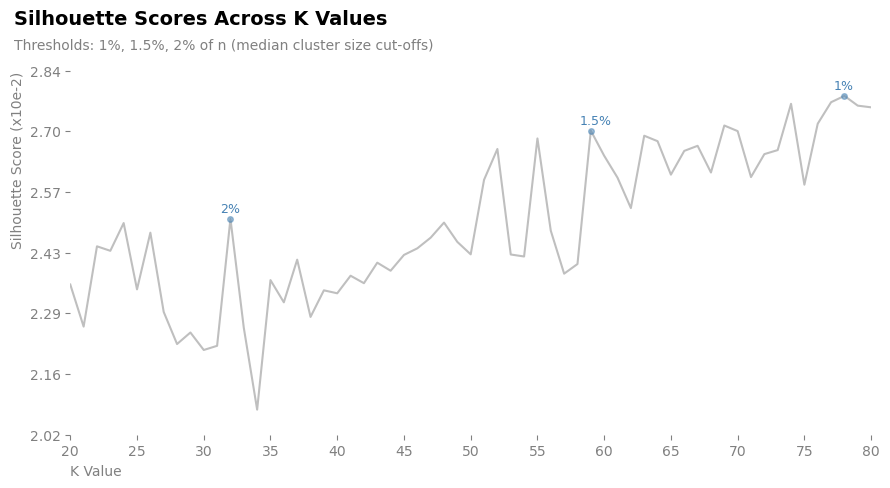

In [14]:
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=metrics_df,
    x="K Value",
    y="Silhouette Score (x10e-2)",
    color="grey",
    alpha=0.5,
)

# Coordinates of the optimal K by threshold for annotation
for i, row in optimal_df.iterrows():
    ax.annotate(
        f"{row['Threshold Percent']}",
        xy=(row["Optimal K"], row["Silhouette Score (x10e-2)"]),
        xytext=(row["Optimal K"] - 0.8, row["Silhouette Score (x10e-2)"] + 0.014),
        fontsize=9,
        color="steelblue",
    )
    ax.plot(
        row["Optimal K"],
        row["Silhouette Score (x10e-2)"],
        "o",
        color="steelblue",
        markersize=4,
        alpha=0.5,
    )

# Clean borders by removing bottom/right spines
sns.despine(right=True, top=True, left=True, bottom=True)

# Set labels and markers to grey for subtlety
ax.set_xlabel("K Value", color="grey")
ax.set_ylabel("Silhouette Score (x10e-2)", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# Set axis alignment and position to the left for better aesthetics
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Remove horizontal padding so the line starts at the y-axis
ax.set_xlim(metrics_df["K Value"].min(), metrics_df["K Value"].max())

# Use data-driven y limits and ticks for robustness
ymin = metrics_df["Silhouette Score (x10e-2)"].min()
ymax = metrics_df["Silhouette Score (x10e-2)"].max()
ypad = max((ymax - ymin) * 0.08, 0.02)
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.xaxis.set_ticks(
    np.arange(metrics_df["K Value"].min(), metrics_df["K Value"].max() + 1, 5)
)
ax.yaxis.set_ticks(np.linspace(ymin - ypad, ymax + ypad, 7))

# format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))

# Title parameters
ax.set_title(
    label="Silhouette Scores Across K Values",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=15,
    loc="left",
    x=-0.07,
    y=1.07,
)

# Add subtitle in axes coordinates so it stays in place across scales
ax.text(
    x=-0.07,
    y=1.05,
    s="Thresholds: 1%, 1.5%, 2% of n (median cluster size cut-offs)",
    fontsize=10,
    color="grey",
    ha="left",
    va="bottom",
    transform=ax.transAxes,
)

plt.tight_layout()
plt.savefig(Config.KMEANS_PLOT_PATH, dpi=300, bbox_inches="tight")

print("\nSilhouette scores across K (number of clusters) values:")
plt.show()

### Redundancy Ratio and Composite Scoring

The redundancy ratio is calculated to assess the distinctiveness of clusters. A low redundancy ratio indicates that clusters are capturing different themes, while a high ratio suggests overlap in the issues represented by clusters.

The composite score combines separation quality and overlap penalty in a single metric:
- Composite score = silhouette score - redundant pair ratio

This definition selects models with strong structure (higher silhouette) and lower thematic duplication (lower redundancy ratio).

In [15]:
# Compute redundant-cluster-pair ratio for each optimal K threshold
def compute_redundancy_ratio(cluster_labels_map: dict) -> float:
    """Proportion of cluster pairs sharing >=50% of top terms (by smaller set size)."""
    label_sets = {
        cid: set(lbl.split(", ")) if isinstance(lbl, str) else set()
        for cid, lbl in cluster_labels_map.items()
    }
    cluster_ids = list(label_sets.keys())
    all_pairs = [
        (a, b) for i, a in enumerate(cluster_ids) for b in cluster_ids[i + 1 :]
    ]
    if not all_pairs:
        return 0.0

    redundant_pairs = 0
    for a, b in all_pairs:
        smaller = min(len(label_sets[a]), len(label_sets[b]))
        if smaller > 0 and len(label_sets[a] & label_sets[b]) / smaller >= 0.5:
            redundant_pairs += 1
    return redundant_pairs / len(all_pairs)


def build_labels_map(
    k: int, cluster_ids: np.ndarray, feature_names: np.ndarray, tfidf_matrix
) -> dict:
    """Build a top-6-term label per cluster using O(n) argpartition."""
    labels_map = {}
    for cid in range(k):
        member_idx = np.where(cluster_ids == cid)[0]
        if len(member_idx) == 0:
            labels_map[cid] = "Empty Cluster"
            continue
        mean_vec = np.array(tfidf_matrix[member_idx].mean(axis=0)).ravel()
        top_idx = np.argpartition(mean_vec, -6)[-6:]
        top_idx = top_idx[np.argsort(mean_vec[top_idx])[::-1]]
        labels_map[cid] = ", ".join(feature_names[top_idx])
    return labels_map


print("Computing redundancy ratios for optimal K values (1-2mins)...")

feature_names = df.columns.to_numpy()

# Cache KMeans fits by k — avoids redundant fitting if multiple thresholds share the same Optimal K
kmeans_cache: dict = {}
redundancy_values = []

for _, opt_row in optimal_df.iterrows():
    best_k = int(opt_row["Optimal K"])
    if best_k not in kmeans_cache:
        kmeans_cache[best_k] = KMeans(
            n_clusters=best_k, random_state=Config.RANDOM_STATE, n_init=10
        ).fit_predict(tfidf_normalised)
    labels_map = build_labels_map(
        best_k, kmeans_cache[best_k], feature_names, tfidf_normalised
    )
    redundancy_values.append(compute_redundancy_ratio(labels_map))

# Composite score: maximise silhouette, minimise redundancy
optimal_df["Redundant Pair Ratio"] = redundancy_values
optimal_df["Composite Score"] = (
    optimal_df["Silhouette Score"] - optimal_df["Redundant Pair Ratio"]
)
optimal_df = optimal_df.sort_values("Composite Score", ascending=False)

optimal_k = int(optimal_df.iloc[0]["Optimal K"])
print(f"Chosen optimal K: {optimal_k}")

display(optimal_df)

Computing redundancy ratios for optimal K values (1-2mins)...
Chosen optimal K: 78


,Threshold Proportion,Threshold Percent,Threshold Abs,Optimal K,Silhouette Score,Silhouette Score (x10e-2),Davies-Bouldin Score,Median Cluster Size,Oversegmentation,Redundant Pair Ratio,Composite Score
58,0.010,1%,137.290,78.0,0.027838,2.783837,4.757749,159.0,False,0.027639,0.000199
12,0.020,2%,274.580,32.0,0.025072,2.507163,5.419286,434.0,False,0.030242,-0.005170
39,0.015,1.5%,205.935,59.0,0.027056,2.705566,4.985921,227.0,False,0.034483,-0.007427


### Cluster labels

The final cluster labels were generated by extracting the top TF-IDF terms for each cluster and combining them into descriptive labels that capture the main themes of the tickets in each cluster.

In [16]:
# Final clustering using optimal_k
print(f"Performing final KMeans clustering with k={optimal_k} (30-60s)...")
kmeans = KMeans(n_clusters=optimal_k, random_state=Config.RANDOM_STATE, n_init=10)
df["KMeans Cluster"] = kmeans.fit_predict(tfidf_normalised)

# Generate top TF-IDF term labels for each cluster
labels_map, label_rows = {}, []

for cid in range(optimal_k):
    idx = np.where(df["KMeans Cluster"] == cid)[0]
    if len(idx) == 0:
        labels_map[cid] = "Empty Cluster"
        label_rows.append(
            {"Cluster ID": cid, "Keywords": "Empty Cluster", "Records": 0}
        )
        continue

    mean_vec = np.array(tfidf_normalised[idx].mean(axis=0)).ravel()
    top_idx = np.argpartition(mean_vec, -6)[-6:]
    top_idx = top_idx[np.argsort(mean_vec[top_idx])[::-1]]
    label_text = ", ".join(feature_names[top_idx])
    labels_map[cid] = label_text
    label_rows.append({"Cluster ID": cid, "Keywords": label_text, "Records": len(idx)})

cluster_labels_df = pd.DataFrame(label_rows).sort_values(by="Records", ascending=False)
df["Cluster Label"] = df["KMeans Cluster"].map(labels_map)

print("Generated cluster label summary:")
display(cluster_labels_df)
cluster_labels_df.to_csv(Config.CLUSTER_LABELS_PATH, index=False)

Performing final KMeans clustering with k=78 (30-60s)...
Generated cluster label summary:


,Cluster ID,Keywords,Records
11,11,"integration, integrate, documentation, step, s...",471
28,28,"investment, analytic, tool, data, data analyti...",443
18,18,"unauthorized, access, unauthorized access, acc...",431
17,17,"issue, software, update, compatibility, proble...",394
43,43,"brand, growth, digital, brand growth, strategy...",322
...,...,...,...
60,60,"azure, microsoft, microsoft azure, teams, inte...",51
53,53,"google cloud, cloud, cloud platform, google, p...",48
54,54,"wifi, router, nest, nest wifi, google nest, wi...",42
73,73,"spss, ibm spss, spss statistics, statistics, i...",32


### Actionability Scoring

Finally, an actionability score is calculated for each cluster using:
- Cohesion contribution (mean similarity weighted by prevalence)
- High-similarity ratio (share of tickets above the global median similarity)

Clusters with high internal consistency and broader operational footprint are scored as more actionable, indicating issues that are both well-defined and recurrent enough to prioritise for improvement.

In [17]:
# Compute cohesion & actionability using centroid-based cosine similarity
# Build per-ticket similarity to assigned KMeans centroid (TF-IDF space)
cluster_ids = df["KMeans Cluster"].to_numpy()
centroids = kmeans.cluster_centers_
centroid_norms = np.linalg.norm(centroids, axis=1)

centroid_similarity = np.zeros(len(cluster_ids), dtype=np.float32)
for cid in range(optimal_k):
    idx = np.where(cluster_ids == cid)[0]
    if len(idx) == 0:
        continue
    denom = centroid_norms[cid]
    if denom == 0:
        continue
    centroid_similarity[idx] = (
        np.asarray(tfidf_normalised[idx].dot(centroids[cid])).ravel() / denom
    )

# Prepare analysis dataframe aligned to clustering output
actionability_df = pd.DataFrame(
    {
        "KMeans Cluster": cluster_ids,
        "Mean Similarity": centroid_similarity,
    }
)
actionability_df["Cluster Label"] = actionability_df["KMeans Cluster"].map(labels_map)

# Cluster-level cohesion summary
cluster_summary_df = (
    actionability_df.groupby("KMeans Cluster", observed=False)
    .agg(
        Cluster_Size=("KMeans Cluster", "size"),
        Mean_Similarity=("Mean Similarity", "mean"),
    )
    .reset_index()
)
cluster_summary_df["Cluster Label"] = cluster_summary_df["KMeans Cluster"].map(
    labels_map
)
cluster_summary_df["Cohesion"] = (
    cluster_summary_df["Mean_Similarity"]
    * cluster_summary_df["Cluster_Size"]
    / len(actionability_df)
)

cluster_summary_df = cluster_summary_df.sort_values("Cohesion", ascending=False)
cluster_summary_df.to_csv(Config.CLUSTER_SUMMARY_PATH, encoding="utf-8", index=False)

print("\nActionability per ticket:")
display(actionability_df)

print("\nCluster-level cohesion summary:")
display(cluster_summary_df)


Actionability per ticket:


,KMeans Cluster,Mean Similarity,Cluster Label
0,23,0.356477,"outage, service, service outage, issue, outage..."
1,64,0.311689,"team, platform, product, support, reach, suppo..."
2,16,0.607616,"payment, billing, update billing, billing info..."
3,64,0.352933,"team, platform, product, support, reach, suppo..."
4,64,0.361787,"team, platform, product, support, reach, suppo..."
...,...,...,...
13724,47,0.479736,"billing, discrepancy, billing discrepancy, inv..."
13725,46,0.511576,"data breach, breach, data, medical, record, me..."
13726,44,0.480765,"analytic tool, tool, analytic, data, data anal..."
13727,14,0.303091,"saas platform, saas, platform, issue, server, ..."



Cluster-level cohesion summary:


,KMeans Cluster,Cluster_Size,Mean_Similarity,Cluster Label,Cohesion
18,18,431,0.491483,"unauthorized, access, unauthorized access, acc...",0.015429
28,28,443,0.417528,"investment, analytic, tool, data, data analyti...",0.013473
11,11,471,0.346838,"integration, integrate, documentation, step, s...",0.011899
43,43,322,0.478061,"brand, growth, digital, brand growth, strategy...",0.011212
38,38,253,0.523147,"security, medical, protocol, datum, medical da...",0.009641
...,...,...,...,...,...
63,63,64,0.476013,"downtime, server, overload, server overload, i...",0.002219
54,54,42,0.683226,"wifi, router, nest, nest wifi, google nest, wi...",0.002090
60,60,51,0.520047,"azure, microsoft, microsoft azure, teams, inte...",0.001932
73,73,32,0.715304,"spss, ibm spss, spss statistics, statistics, i...",0.001667


### Top 10 Clusters

The top 10 clusters are ranked by the normalised actionability score, which combines:
- Cohesion contribution (prevalence-weighted mean similarity)
- High-similarity ratio

This ranking surfaces clusters that are both internally coherent and operationally consequential.

In [18]:
# Create actionability ranking based on cohesion contribution and high-similarity concentration
overall_median_similarity = actionability_df["Mean Similarity"].median()

# Flag each ticket as High (above median similarity) or Low
actionability_df["Similarity Tier"] = np.where(
    actionability_df["Mean Similarity"] >= overall_median_similarity, "High", "Low"
)

actionability_df.to_csv(Config.ACTIONABILITY_PATH, encoding="utf-8", index=False)

# Compute per-cluster proportion of High-tier tickets
ratio_df = (
    actionability_df.groupby("KMeans Cluster", observed=False)["Similarity Tier"]
    .value_counts(normalize=True)
    .rename("Ratio")
    .reset_index()
)

high_ratio = ratio_df.loc[
    ratio_df["Similarity Tier"] == "High", ["KMeans Cluster", "Ratio"]
].rename(columns={"Ratio": "High Ratio"})

# Merge cohesion by cluster (safe alignment; keep all clusters)
actionability_dist = cluster_summary_df[
    ["KMeans Cluster", "Cohesion", "Cluster Label"]
].merge(high_ratio, on="KMeans Cluster", how="left")

# Fill clusters with no High tickets
actionability_dist["High Ratio"] = actionability_dist["High Ratio"].fillna(0.0)

# Map records from cluster_labels_df to actionability_dist (safe alignment)
records_map = cluster_labels_df.set_index("Cluster ID")["Records"].to_dict()
actionability_dist["Records"] = actionability_dist["KMeans Cluster"].map(records_map)

cohesion_max = actionability_dist["Cohesion"].max()
high_ratio_max = actionability_dist["High Ratio"].max()

if pd.isna(cohesion_max) or cohesion_max == 0:
    cohesion_max = 1.0
if pd.isna(high_ratio_max) or high_ratio_max == 0:
    high_ratio_max = 1.0

# Raw weighted score, then normalised to 0-1 for easier interpretation
raw_actionability = 0.5 * (actionability_dist["Cohesion"] / cohesion_max) + 0.3 * (
    actionability_dist["High Ratio"] / high_ratio_max
)
actionability_dist["Actionability Score"] = raw_actionability / 0.8

# Top 10 most actionable clusters
top10_actionable = (
    actionability_dist.sort_values("Actionability Score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)[
    [
        "KMeans Cluster",
        "Records",
        "Cluster Label",
        "Cohesion",
        "High Ratio",
        "Actionability Score",
    ]
]

print("\nTop 10 most actionable clusters:")
display(
    top10_actionable.style.format(
        {
            "Cohesion": "{:.4f}",
            "High Ratio": "{:.2%}",
            "Actionability Score": "{:.4f}",
        }
    )
)

actionability_dist.to_csv(Config.PRIORITY_PATH, encoding="utf-8", index=False)


Top 10 most actionable clusters:


,KMeans Cluster,Records,Cluster Label,Cohesion,High Ratio,Actionability Score
0,18,431,"unauthorized, access, unauthorized access, access attempt, security, attempt",0.0154,65.43%,0.8704
1,38,253,"security, medical, protocol, datum, medical datum, security protocol",0.0096,85.38%,0.7107
2,28,443,"investment, analytic, tool, data, data analytic, optimize",0.0135,37.02%,0.6846
3,43,322,"brand, growth, digital, brand growth, strategy, digital strategy",0.0112,60.25%,0.6801
4,69,257,"breach, security breach, security, medical, hospital, datum",0.0094,76.26%,0.6662
5,15,211,"investment, analytic, investment strategy, service, analytic service, data analytic",0.0082,87.68%,0.6625
6,76,260,"marketing, brand, digital marketing, digital, strategy, marketing strategy",0.0095,70.38%,0.6482
7,39,138,"brand, digital, strategy, growth, brand growth, social medium",0.0061,97.83%,0.6151
8,5,163,"service, digital, brand, digital strategy, strategy, growth",0.0068,90.18%,0.6126
9,4,217,"breach, data breach, security, data, healthcare, hospital",0.0078,77.42%,0.6059


### Findings

Threshold screening returns multiple candidate K values by design (one per threshold). The final K is selected after applying the redundancy penalty and ranking candidates by composite score.

See the programmatic summary cell above for variable-driven values of:
- Candidate K by threshold
- Composite scores by threshold
- Final selected K

#### Cluster Model Performance
- Evaluation range: configured K search range
- Selection rule: maximise (silhouette score - redundant pair ratio)
- Metrics were computed on the full dataset
- Over-segmentation is controlled via threshold-specific median-cluster cut-offs

#### Cohesion vs Prevalence
Cohesion and prevalence represent different properties:
- Cohesion: within-cluster consistency, measured by centroid similarity
- Prevalence: cluster footprint, measured as share of total tickets

In this pipeline, the reported Cohesion value is a cohesion contribution term (mean similarity multiplied by prevalence).

#### Actionability Interpretation
Actionability is a normalised 0-1 score combining:
- Cohesion contribution
- High-similarity ratio

Higher-scoring clusters are both structurally coherent and recurrent enough to prioritise for process improvement.